In [51]:
import os
os.chdir(r"C:/Users/priya/UVA-iGEM-2025-Model-/ECMpy")
print(os.getcwd())
import cobra 
from cobra.io import save_json_model, write_sbml_model
from cobra import Model, Reaction, Metabolite
import pandas as pd
import sys
sys.path.append(r'./code/')
from cobrapy_ec_model_function import *
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import cobra.test
from cobra.flux_analysis import production_envelope
sys.path.append('./dfba')

import dfba_helpers
print(dfba_helpers.__file__)
import importlib
import dfba_helpers
importlib.reload(dfba_helpers)
from dfba_helpers import *

C:\Users\priya\UVA-iGEM-2025-Model-\ECMpy
C:\Users\priya\UVA-iGEM-2025-Model-\ECMpy\./dfba\dfba_helpers.py


In [2]:
# The genome-scale metabolic model for constructing the enzyme-constrained model
model_name = './model/iML1515_new.xml' 

# Reaction-kcat file.
# eg. AADDGT,64.41327046 #s-1
reaction_kcat_file = './data/nc_machine_learning_kapp.json'
select_key = 'kappmax_ensemble_model_s-1'

# Gene-abundance file organized from PAXdb
# eg. b0789,1.1
gene_abundance_file = "./data/parsed_gene_abundance_from_paxdb.csv"

# Gene-molecular_weight file organized from EcoCyc
# eg. b3500,48.77251
gene_molecular_weight_file = "./data/gene_molecular_weight.csv"

reaction_gene_subunit_file = "./data/reaction_gene_subunit.csv"
c13reaction_file = './data/C13reaction.csv' 
media_file = './data/final_media(final_media).csv'


#output files
gene_outfile = "./analysis/genes.csv"
gpr_outfile = "./analysis/all_reaction_GPR.csv"
reaction_gene_subunit_MW_file = "./analysis/reaction_gene_subunit_MW.csv"
reaction_MW_file = "./analysis/reaction_MW.csv"
reaction_kcat_MW_file = "./analysis/reaction_kcat_MW.csv"
json_output_file="./model/iML1515_irr_enz_constraint.json"
ECMpy_fluxes_outfile = './analysis/ECMpy_ori_solution_df_pfba.csv'
GEM_fluxes_outfile = './analysis/Orimodel_solution_df_pfba.csv'

In [3]:
model = cobra.io.read_sbml_model(model_name)
#modifying bounds to account for reversible reactions for media conditions 
df = pd.read_csv(media_file)
df.columns = df.columns.str.strip()
for _, row in df.iterrows():
    rxn_id = row['Original Reaction']

    # Only proceed if the reaction ID is present and non-null
    if pd.notna(rxn_id):
        try:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.lower_bound = -1000.0  # allow uptake
            # Optionally: cap export if you want to avoid unintended fluxes
            # rxn.upper_bound = 1000.0  
        except KeyError:
            print(f"⚠️ Reaction {rxn_id} not found in model, skipping.")

print(model.reactions.get_by_id('EX_xyl__D_e').bounds)
convert_to_irreversible(model)
#split isoenzyme
model = isoenzyme_split(model)
model
modified_model = cobra.io.write_sbml_model(model, 'modified_model.xml')

(-1000.0, 1000.0)


In [5]:
[genes,gpr_relationship] = get_genes_and_gpr(model,gene_outfile,gpr_outfile)

In [6]:
reaction_gene_subunit_MW = get_reaction_gene_subunit_MW(reaction_gene_subunit_file,gene_molecular_weight_file,reaction_gene_subunit_MW_file)
reaction_gene_subunit_MW.head(5)

,name,gene_reaction_rule,subunit_num,subunit_mw
ALATA_D2_num1,D-alanine transaminase,b2551,2,45.31659
ALATA_D2_num2,D-alanine transaminase,b0870,4,36.49471
SHCHD2,Sirohydrochlorin dehydrogenase (NAD),b3368,2,49.9514
CPPPGO,Coproporphyrinogen oxidase (O2 required),b2436,2,34.32263
GTHOr,Glutathione oxidoreductase,b3500,2,48.77251


In [7]:
# reaction-gene-subunit-MW file. 
# eg. ALATA_D2,D-alanine transaminase,b2551 or b0870,45.31659 or 36.49471 ,2 or 4 
reaction_MW = calculate_reaction_mw(reaction_gene_subunit_MW_file,reaction_MW_file)
reaction_MW.head(5)

,MW
ALATA_D2_num1,90.6332
ALATA_D2_num2,145.9788
SHCHD2,99.9028
CPPPGO,68.6453
GTHOr,97.545


In [8]:
reaction_kcat_mw = calculate_reaction_kcat_mw(reaction_kcat_file, reaction_MW_file, reaction_kcat_MW_file,select_key)
reaction_kcat_mw.head(5)

,MW,kcat,kcat_MW
ALATA_D2_num1,90.6332,9300.506998,102.616999
ALATA_D2_num2,145.9788,9300.506998,63.711354
SHCHD2,99.9028,1224.000000,12.251909
CPPPGO,68.6453,900.000000,13.110876
GTHOr,97.5450,25901.616143,265.535047


In [9]:
f = calculate_f(genes, gene_abundance_file, gene_molecular_weight_file)
f

0.9521446776017833

In [10]:
#The enzyme mass fraction 
f = f
print(f)
# The total protein fraction in cell.
ptot = 0.56 
# The approximated average saturation of enzyme.
sigma = 1 #kapp data sigma is 1
# Lowerbound  of enzyme concentration constraint. 
lowerbound = 0   
upperbound = round(ptot * f * sigma, 3)

0.9521446776017833


In [11]:
trans_model2enz_json_model_split_isoenzyme('modified_model.xml', reaction_kcat_MW_file, f, ptot, sigma, lowerbound, upperbound, json_output_file)

enz_model=get_enzyme_constraint_model(json_output_file)

In [12]:
f = f
# The total protein fraction in cell.
ptot = 0.56 
# The approximated average saturation of enzyme.
sigma = 1 #kapp data sigma is 1
# Lowerbound  of enzyme concentration constraint. 
lowerbound = 0   
upperbound = round(ptot * f * sigma, 3)

new_model_name = './modified_model.xml' 
c13reaction_file = './data/C13reaction.csv' 
initial_conc_file = './dfba/final_media(initial_conc).csv'

#max kcat for EC number selected from BRENDA and SABIO-RK database(use autoPACMEN)
kcat_database_combined_file= './data/Brenda_sabio_combined_select.json'

reaction_kcat_MW_file = './analysis/reaction_kcat_MW.csv'
fluxes_infile_ori = './analysis/ECMpy_ori_solution_df_pfba.csv'
json_model_path = './model/iML1515_irr_enz_constraint.json'

enz_ratio=0.01
reaction_enz_usage_file = './analysis/ECMpy_adj_round1_reaction_enz_usage_df.csv'
reaction_kcat_MW_round1_outfile = './analysis/reaction_change_by_enzuse.csv'
json_round1_output_file = './model/iML1515_irr_enz_constraint_adj_round1.json'
round1_fluxes_outfile = './analysis/ECMpy_adj_round1_solution_df_pfba.csv'
c13_percentage=0.1
#json_round2_output_file= './model/iML1515_irr_enz_constraint_adj_round2.json'
#reaction_kcat_MW_round2_outfile = './analysis/reaction_change_by_c13.csv'
#round2_fluxes_outfile = './analysis/ECMpy_adj_round2_solution_df_pfba.csv'

ECMpy_solution_df_pfba_file='./analysis/ECMpy_solution_df_pfba.csv'

In [13]:
enz_model=get_enz_model_use_enz_usage_by_eckcat(enz_ratio,json_model_path,fluxes_infile_ori, reaction_kcat_MW_file,\
                                      reaction_enz_usage_file,kcat_database_combined_file, new_model_name
                                                
                                                , \
                                      f, ptot, sigma, lowerbound, upperbound, json_round1_output_file, \
                                      reaction_kcat_MW_round1_outfile)
enz_model_pfba_solution = get_fluxes_detail_in_model(enz_model,round1_fluxes_outfile,reaction_kcat_MW_round1_outfile)

c13reaction_2_enz_model_diff = get_diff_reaction_use_c13(c13reaction_file,enz_model_pfba_solution)
print (c13reaction_2_enz_model_diff)

need changing reaction: 
['GLCDpp_num2', 'RBFSa', 'ACCOAC', 'ATPS4rpp_num2', 'GLNS', 'CYTBO3_4pp', 'GTPCI', 'MCOATA']
changed reaction: 
['RBFSa', 'ACCOAC', 'GLNS', 'GTPCI', 'MCOATA']
['ACONTb', 'ICL', 'MDH', 'ICDHyr', 'PYK', 'GHMT2r', 'PSP_L', 'TPI', 'SUCOAS_reverse', 'ACKr_reverse', 'SUCDi', 'PSERT', 'PGCD', 'MALS', 'ACONTa', 'PGI', 'FBA', 'PDH', 'PFK', 'CS', 'PPC', 'PTAr', 'AKGDH']


In [14]:
orig_df = pd.read_csv(reaction_kcat_MW_file, header=None)
calib_df = pd.read_csv(reaction_kcat_MW_round1_outfile, header=None)

# Define reactions to protect
protected_rxns = ['PGCD','SERAT','SERAT_reverse']

# Overwrite calibrated kcat with original for protected reactions
for rxn in protected_rxns:
    orig_kcat = orig_df.loc[orig_df[0] == rxn, 2].values
    if len(orig_kcat) > 0:
        calib_df.loc[calib_df[0] == rxn, 2] = orig_kcat[0]

# Save corrected file
calib_df.to_csv(reaction_kcat_MW_round1_outfile, index=False)

In [15]:
enz_model=get_enzyme_constraint_model(json_round1_output_file)

main function 
- add in conditional kill switch trigger

In [56]:
results = dfba_simulation(
    model=enz_model,
    steps=30,
    dt=0.1,
    media_file=media_file,
    column_name='l + 100',
    initial_conc_file=initial_conc_file
)

results.to_csv("dfba_results.csv", index=False)

sol1 <Solution 0.699 at 0x1aa17df9a30>
sol1 <Solution 0.746 at 0x1aa17decb80>
sol1 <Solution 0.746 at 0x1aa1be81400>
sol1 <Solution 0.746 at 0x1aa17decb80>
sol1 <Solution 0.746 at 0x1aa1be81ac0>
sol1 <Solution 0.746 at 0x1aa17decca0>
sol1 <Solution 0.746 at 0x1aa1be81af0>
sol1 <Solution 0.746 at 0x1aa17df9370>
sol1 <Solution 0.746 at 0x1aa1be81e50>
sol1 <Solution 0.743 at 0x1aa17decdf0>
sol1 <Solution 0.743 at 0x1aa1be81c10>
sol1 <Solution 0.743 at 0x1aa17dec460>
sol1 <Solution 0.743 at 0x1aa1be813a0>
sol1 <Solution 0.743 at 0x1aa17decdf0>
sol1 <Solution 0.743 at 0x1aa1be81be0>
sol1 <Solution 0.743 at 0x1aa17dec280>
sol1 <Solution 0.743 at 0x1aa1be81bb0>
sol1 <Solution 0.743 at 0x1aa17decdf0>
sol1 <Solution 0.743 at 0x1aa1be81ee0>
sol1 <Solution 0.743 at 0x1aa17dec280>
sol1 <Solution 0.743 at 0x1aa1be81af0>
sol1 <Solution 0.743 at 0x1aa17decca0>
sol1 <Solution 0.743 at 0x1aa1be81250>
sol1 <Solution 0.743 at 0x1aa17decca0>
sol1 <Solution 0.743 at 0x1aa1be81e50>
sol1 <Solution 0.743 at 0

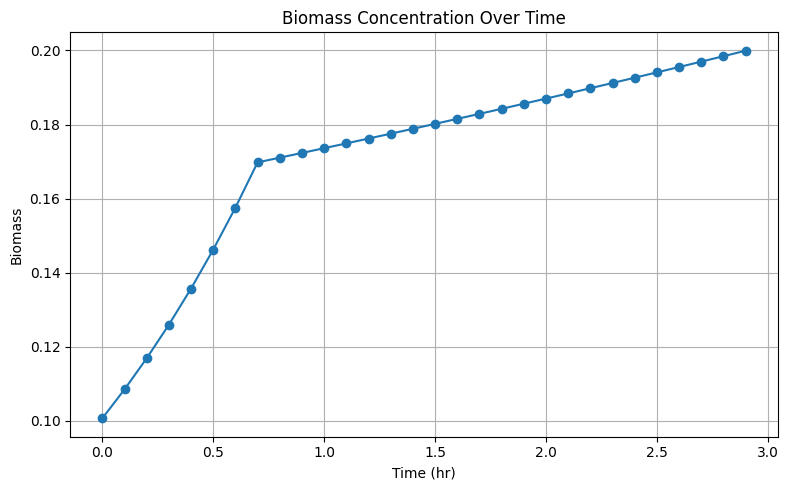

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(results['time_hr'], results['biomass'], marker='o')
plt.xlabel('Time (hr)')
plt.ylabel('Biomass')
plt.title('Biomass Concentration Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

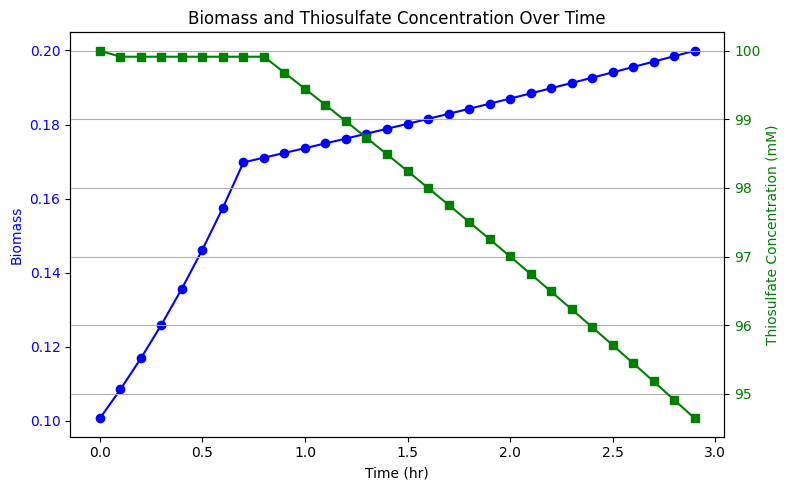

In [58]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot biomass on the left y-axis
ax1.plot(results['time_hr'], results['biomass'], color='blue', marker='o', label='Biomass')
ax1.set_xlabel('Time (hr)')
ax1.set_ylabel('Biomass', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot thiosulfate concentration on the right y-axis
ax2.plot(results['time_hr'], results['thiosulfate_concentration'], color='green', marker='s', label='Thiosulfate Concentration')
ax2.set_ylabel('Thiosulfate Concentration (mM)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Title and layout
plt.title('Biomass and Thiosulfate Concentration Over Time')
fig.tight_layout()
plt.grid(True)
plt.show()

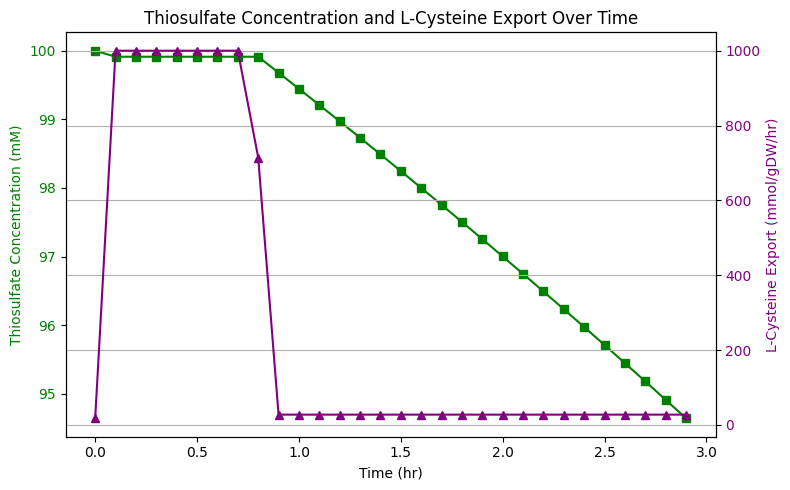

In [59]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# thiosulfate concentration on the left y-axis
ax1.plot(results['time_hr'], results['thiosulfate_concentration'], color='green', marker='s', label='Thiosulfate Concentration')
ax1.set_xlabel('Time (hr)')
ax1.set_ylabel('Thiosulfate Concentration (mM)', color='green')
ax1.tick_params(axis='y', labelcolor='green')

#second y-axis for L-cysteine export
ax2 = ax1.twinx()

# Plot L-cysteine export flux
ax2.plot(results['time_hr'], results['l_cys_export'], color='purple', marker='^', label='L-Cysteine Export')
ax2.set_ylabel('L-Cysteine Export (mmol/gDW/hr)', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Title and layout
plt.title('Thiosulfate Concentration and L-Cysteine Export Over Time')
fig.tight_layout()
plt.grid(True)
plt.show()